<div style="background:linear-gradient(135deg,#4a044e 0%,#a21caf 55%,#e879f9 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#f5d0fe;font-weight:700;text-transform:uppercase">Chapter 146 · Advanced &amp; Applied Topics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Deep Learning Primer</div>
  <div style="font-size:15px;color:#fae8ff;max-width:740px;line-height:1.6">A neuron is logistic regression; a network stacks them with a nonlinear twist between. We compute one neuron by hand, plot the activations, watch a linear model fail on a ring-shaped problem, then build and train a small PyTorch network that solves it, boundary and all.</div>
</div>

Run top to bottom. Uses **numpy**, **scikit-learn**, **matplotlib**, and **PyTorch**. Everything trains in seconds on a CPU.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch, torch.nn as nn
np.random.seed(46); torch.manual_seed(46)
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
FU, BL, GR, RD = "#a21caf", "#2563eb", "#16a34a", "#dc2626"
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "deep-learning-primer--sensor-qc.xlsx"
try:
    df = pd.read_excel("../../data/" + fn)
except FileNotFoundError:
    df = pd.read_excel(BASE + fn)
print(df.shape); print(df.head())

(1200, 3)
   sensor_a  sensor_b  passed_qc
0     2.434    -0.347          0
1    -2.537    -2.739          0
2    -1.365     2.489          0
3     0.731     1.895          1
4     2.604    -0.033          0


## DEMO 1 &middot; A neuron by hand
A neuron is `a = f(w . x + b)`: weight each input, add a bias, squash. With a sigmoid, that is exactly logistic regression, one line of arithmetic.

In [2]:
w = np.array([0.7, -0.4])   # weights
b = 0.1                     # bias
x = np.array([1.5, 2.0])    # one input (two features)
z = w @ x + b               # weighted sum + bias
a = 1 / (1 + np.exp(-z))    # sigmoid activation
print(f"weighted sum  z = w . x + b = {z:.2f}")
print(f"activation    a = sigmoid(z) = {a:.3f}   <- this neuron's output")

weighted sum  z = w . x + b = 0.35
activation    a = sigmoid(z) = 0.587   <- this neuron's output


## DEMO 2 &middot; The activation functions
The nonlinearity between layers is what makes depth matter. Sigmoid and tanh squash; ReLU (`max(0, x)`) is the modern default because it is cheap and keeps gradients alive.

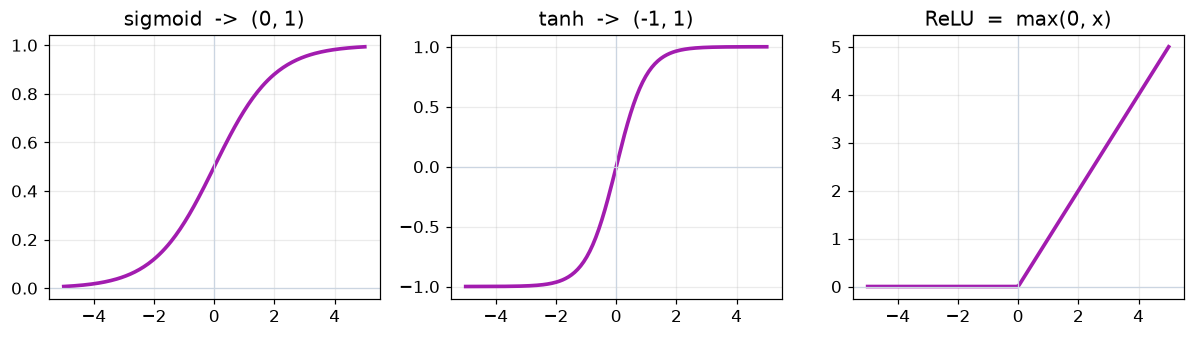

In [3]:
xs = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
ax[0].plot(xs, 1/(1+np.exp(-xs)), color=FU, lw=2.4); ax[0].set_title("sigmoid  ->  (0, 1)")
ax[1].plot(xs, np.tanh(xs), color=FU, lw=2.4); ax[1].set_title("tanh  ->  (-1, 1)")
ax[2].plot(xs, np.maximum(0, xs), color=FU, lw=2.4); ax[2].set_title("ReLU  =  max(0, x)")
for a_ in ax: a_.axhline(0, color="#cbd5e1", lw=0.8); a_.axvline(0, color="#cbd5e1", lw=0.8)
plt.tight_layout(); plt.show()

## DEMO 3 &middot; Explore first: a ring a line cannot cut
A part passes when its two sensor readings put it in a mid-band, a ring in the sensor plane. Plot it, then watch logistic regression (a single straight boundary) struggle.

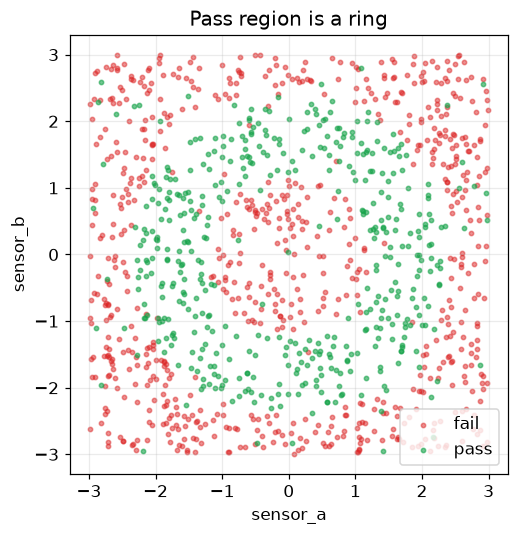

Logistic regression (linear) test accuracy = 0.614  <- barely above guessing


In [4]:
X = df[["sensor_a", "sensor_b"]].values
y = df["passed_qc"].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

fig, ax = plt.subplots(figsize=(5.4, 5))
ax.scatter(X[y==0,0], X[y==0,1], s=8, color=RD, alpha=0.5, label="fail")
ax.scatter(X[y==1,0], X[y==1,1], s=8, color=GR, alpha=0.6, label="pass")
ax.set_xlabel("sensor_a"); ax.set_ylabel("sensor_b"); ax.set_title("Pass region is a ring"); ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

lr = LogisticRegression().fit(Xtr, ytr)
acc_lr = accuracy_score(yte, lr.predict(Xte))
print(f"Logistic regression (linear) test accuracy = {acc_lr:.3f}  <- barely above guessing")

## DEMO 4 &middot; Build and train a network in PyTorch
Two hidden layers of 16 ReLU units, about 337 weights. The training loop is the whole of deep learning: forward pass, loss, backward pass (backprop), step. Repeat.

trainable parameters: 337


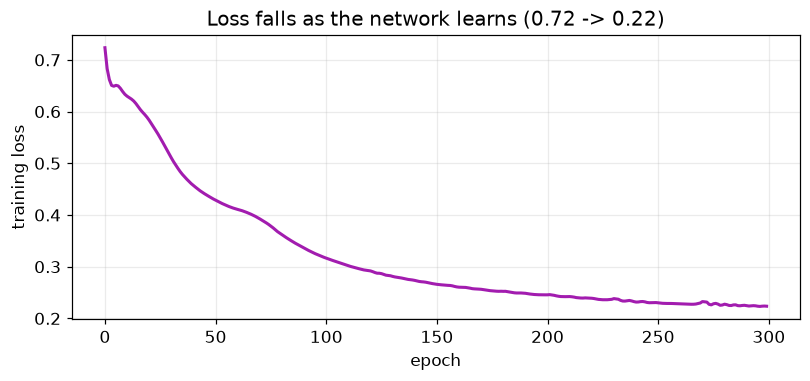

In [5]:
Xtr_t = torch.tensor(Xtr, dtype=torch.float32); ytr_t = torch.tensor(ytr, dtype=torch.float32).unsqueeze(1)
Xte_t = torch.tensor(Xte, dtype=torch.float32); yte_t = torch.tensor(yte, dtype=torch.float32).unsqueeze(1)

model = nn.Sequential(nn.Linear(2, 16), nn.ReLU(),
                      nn.Linear(16, 16), nn.ReLU(),
                      nn.Linear(16, 1))                      # logits out
opt = torch.optim.Adam(model.parameters(), lr=0.02)
loss_fn = nn.BCEWithLogitsLoss()
print("trainable parameters:", sum(p.numel() for p in model.parameters()))

losses = []
for epoch in range(300):
    opt.zero_grad()                 # reset gradients
    logits = model(Xtr_t)           # forward pass
    loss = loss_fn(logits, ytr_t)   # how wrong?
    loss.backward()                 # backprop: gradients for every weight
    opt.step()                      # step downhill
    losses.append(loss.item())

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(losses, color=FU, lw=2); ax.set_xlabel("epoch"); ax.set_ylabel("training loss")
ax.set_title(f"Loss falls as the network learns ({losses[0]:.2f} -> {losses[-1]:.2f})")
plt.tight_layout(); plt.show()

## DEMO 5 &middot; The boundary it learned
The trained network reaches far higher accuracy, and plotting its predictions over the whole plane shows why: the boundary has bent into a ring.

Neural network test accuracy = 0.911   (logistic was 0.614)


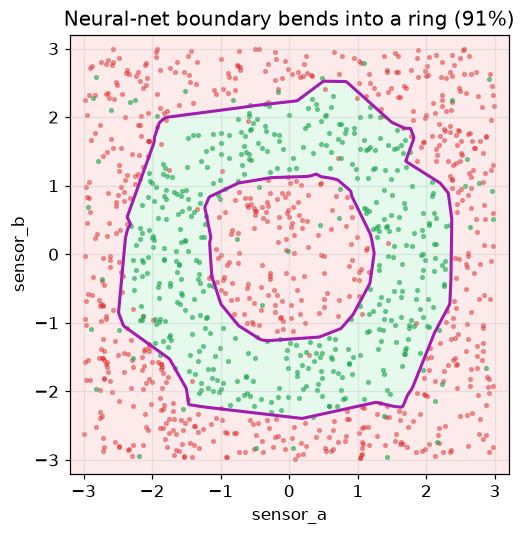

In [6]:
with torch.no_grad():
    acc_mlp = ((torch.sigmoid(model(Xte_t)) > 0.5).float() == yte_t).float().mean().item()
print(f"Neural network test accuracy = {acc_mlp:.3f}   (logistic was {acc_lr:.3f})")

# decision boundary over a grid
gx, gy = np.meshgrid(np.linspace(-3.2, 3.2, 300), np.linspace(-3.2, 3.2, 300))
grid = torch.tensor(np.c_[gx.ravel(), gy.ravel()], dtype=torch.float32)
with torch.no_grad():
    zz = torch.sigmoid(model(grid)).numpy().reshape(gx.shape)
fig, ax = plt.subplots(figsize=(5.4, 5))
ax.contourf(gx, gy, zz, levels=[0, 0.5, 1], colors=["#fde8e8", "#e3f9ec"], alpha=0.9)
ax.contour(gx, gy, zz, levels=[0.5], colors=[FU], linewidths=2)
ax.scatter(X[y==0,0], X[y==0,1], s=6, color=RD, alpha=0.4)
ax.scatter(X[y==1,0], X[y==1,1], s=6, color=GR, alpha=0.5)
ax.set_title(f"Neural-net boundary bends into a ring ({acc_mlp:.0%})"); ax.set_aspect("equal")
ax.set_xlabel("sensor_a"); ax.set_ylabel("sensor_b")
plt.tight_layout(); plt.show()

### Wrap-up
Same data, same optimizer, same loss: the only difference between **61%** and **91%** was two hidden layers and their ReLU activations, bending a straight boundary into a ring. That is deep learning in miniature, forward pass, loss, backprop, repeat, scaled from 337 parameters to billions for the models behind modern image and language systems. Next in Part XXIV: **Recommendation Systems**.